<a href="https://colab.research.google.com/github/Kethellem/cursopython/blob/main/ClustersCliente.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [25]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report
from imblearn.over_sampling import SMOTE
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_curve, roc_auc_score, classification_report

In [2]:
from google.colab import files
uploaded = files.upload()

Saving Mall_Customers.csv to Mall_Customers.csv


In [16]:
# Carregando o dataset
df = pd.read_csv("Mall_Customers.csv")

# Visualizando as primeiras linhas
df.head()


,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [4]:
# Informações gerais
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


In [6]:
# Estatísticas descritivas
df.describe()

,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


In [8]:
# Verificando valores ausentes
df.isnull().sum()

,0
CustomerID,0
Gender,0
Age,0
Annual Income (k$),0
Spending Score (1-100),0


O dataset não possui valores ausentes. Isso significa que não precisamos aplicar técnicas de imputação.



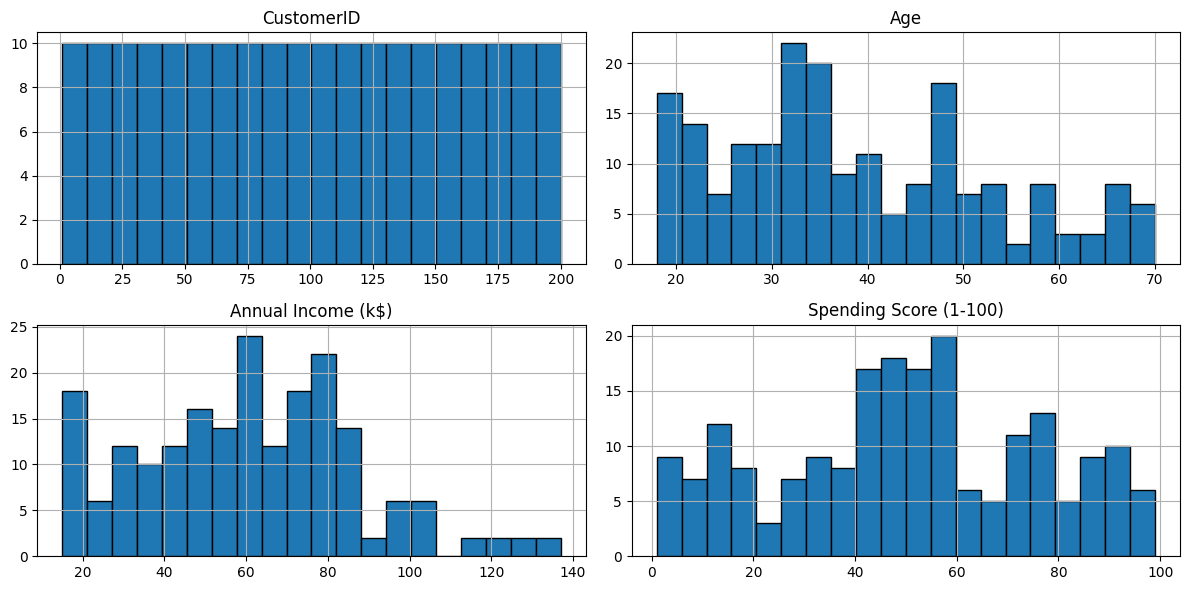

In [10]:
# Distribuição de variáveis numéricas
df.hist(figsize=(12,6), bins=20, edgecolor='black')
plt.tight_layout()
plt.show()

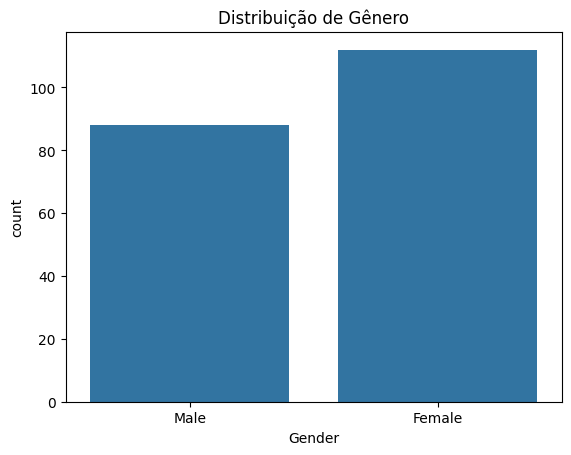

In [13]:
# Distribuição de variável categórica (Gender)
sns.countplot(data=df, x="Gender")
plt.title("Distribuição de Gênero")
plt.show()

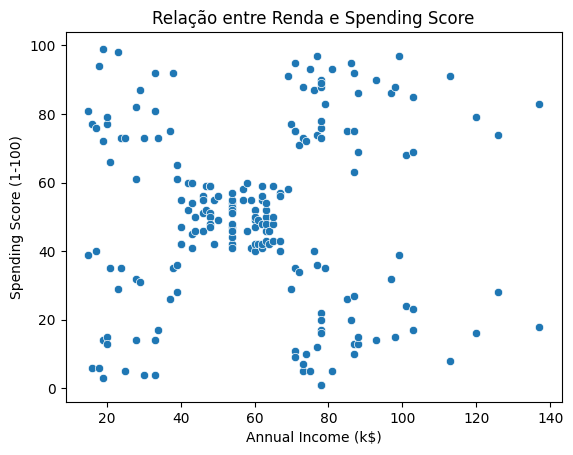

In [14]:
#  Relação entre Renda e Spending Scor
sns.scatterplot(data=df, x="Annual Income (k$)", y="Spending Score (1-100)")
plt.title("Relação entre Renda e Spending Score")
plt.show()


In [17]:
# Verificando ddos duplicados
df.duplicated().sum()

np.int64(0)

Nenhuma linha duplicada foi encontrada

In [18]:
# Removendo colunas sem relevancia para o modelo
df_clean = df.drop(columns=["CustomerID"])
df_clean.head()

,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,Male,19,15,39
1,Male,21,15,81
2,Female,20,16,6
3,Female,23,16,77
4,Female,31,17,40


CustomerID não contém informação util pois é apenas um identificador.

In [19]:
# Transformando variável categóricas (Gender) para (números)
df_clean["Gender"] = df_clean["Gender"].map({"Male": 0, "Female": 1})
df_clean.head()

,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,0,19,15,39
1,0,21,15,81
2,1,20,16,6
3,1,23,16,77
4,1,31,17,40


O K‑Means calcula distâncias entre pontos. Ele não entende texto, então precisamos converter para números.


In [20]:
# Padronização das variáveis com StandardScaler

scaler = StandardScaler()
df_scaled = scaler.fit_transform(df_clean)

df_scaled[:5]


array([[-1.12815215, -1.42456879, -1.73899919, -0.43480148],
       [-1.12815215, -1.28103541, -1.73899919,  1.19570407],
       [ 0.88640526, -1.3528021 , -1.70082976, -1.71591298],
       [ 0.88640526, -1.13750203, -1.70082976,  1.04041783],
       [ 0.88640526, -0.56336851, -1.66266033, -0.39597992]])

Coloquei todas as variáveis na mesma escala
- Média = 0
- Desvio padrão = 1
Isso evits que renda ou idade tenham mais peso que o Spending Score melhorando a qualidade dos clusters.


In [21]:
# Dataset preparada
df_final = pd.DataFrame(df_scaled, columns=df_clean.columns)
df_final.head()


,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,-1.128152,-1.424569,-1.738999,-0.434801
1,-1.128152,-1.281035,-1.738999,1.195704
2,0.886405,-1.352802,-1.700830,-1.715913
3,0.886405,-1.137502,-1.700830,1.040418
4,0.886405,-0.563369,-1.662660,-0.395980


Agora o modelo está pronto para receber o K‑Means com muito mais precisão.

Antes de rodar o K‑Means, precisamos definir o valor de K.
O método mais usado é o Elbow Method, que analisa a inércia (distância interna dos pontos ao centro do cluster).


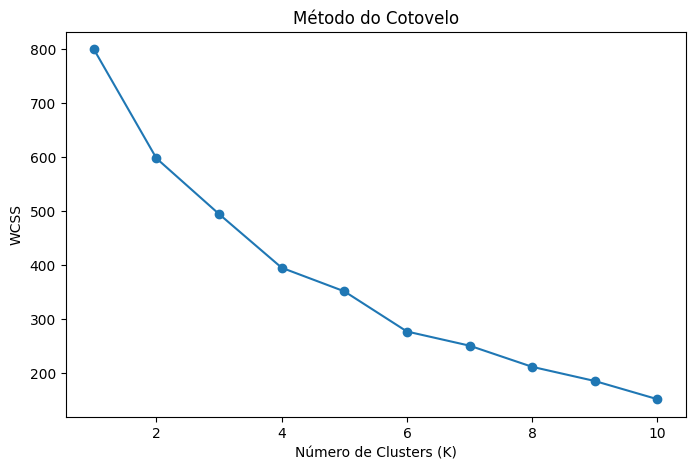

In [26]:
# Escolhendo o número de clusters (Método do cotovelo)
wcss = []  # Within-Cluster Sum of Squares

for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(df_final)
    wcss.append(kmeans.inertia_)

plt.figure(figsize=(8,5))
plt.plot(range(1, 11), wcss, marker='o')
plt.title("Método do Cotovelo")
plt.xlabel("Número de Clusters (K)")
plt.ylabel("WCSS")
plt.show()




O gráfico mostra que a redução da inércia desacelera após K=5.
Isso indica que 5 grupos capturam bem a estrutura dos dados.


In [27]:
# Aplicando o K-Means com 5 clusters
kmeans = KMeans(
    n_clusters=5,
    init="k-means++",
    n_init=20,
    max_iter=300,
    random_state=42
)

kmeans.fit(df_final)

# Adicionando o cluster ao dataframe original
df["Cluster"] = kmeans.labels_

df.head()


,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100),Cluster
0,1,Male,19,15,39,1
1,2,Male,21,15,81,1
2,3,Female,20,16,6,0
3,4,Female,23,16,77,4
4,5,Female,31,17,40,0


Depois que o K‑Means atribui um cluster a cada cliente, o próximo passo é entender o que cada grupo representa.
Para isso, analisamos:idade média ,renda média ,spending score médio e distribuição por gênero



In [28]:
# Estatísticas por Cluster
df.groupby("Cluster").mean(numeric_only=True)


,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
Cluster,,,,
0,77.625000,48.791667,50.333333,36.395833
1,97.820513,28.410256,58.230769,70.717949
2,67.821429,57.214286,46.785714,38.714286
3,170.793103,38.896552,94.172414,21.827586
4,101.910714,28.392857,60.428571,68.178571


Esse comando calcula a média das variáveis numéricas dentro de cada cluster.
Assim conseguimos entender o “cliente médio” de cada grupo — idade média, renda média e spending score médio.
É a base para interpretar o perfil de cada cluster.


In [29]:
#Contagem de clientes por cluster
df["Cluster"].value_counts()

,count
Cluster,
4,56
0,48
1,39
3,29
2,28


Aqui verificamos quantos clientes pertencem a cada cluster.
Isso ajuda a identificar se algum grupo ficou muito pequeno ou muito grande, o que pode indicar necessidade de ajustar o número de clusters.


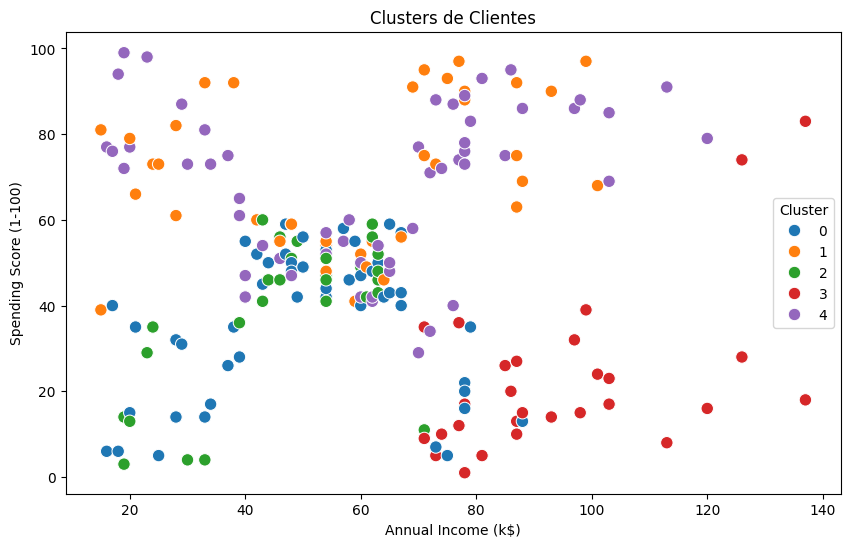

In [31]:
# Visualização dos clusters (renda x spending score)

plt.figure(figsize=(10,6))
sns.scatterplot(
    data=df,
    x="Annual Income (k$)",
    y="Spending Score (1-100)",
    hue="Cluster",
    palette="tab10",
    s=80
)
plt.title("Clusters de Clientes")
plt.show()

Esse gráfico mostra como os clusters se distribuem em relação à renda anual e ao spending score.
É a visualização mais importante do projeto, pois revela claramente os grupos formados pelo K-Means.
Cada cor representa um cluster diferente.


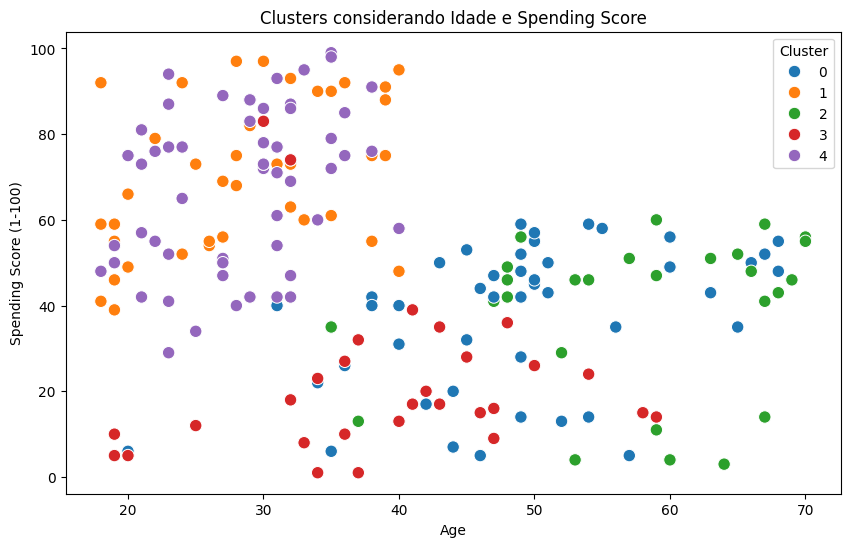

In [32]:
# Visualização dos clusters (Idade x Spending Score)
plt.figure(figsize=(10,6))
sns.scatterplot(
    data=df,
    x="Age",
    y="Spending Score (1-100)",
    hue="Cluster",
    palette="tab10",
    s=80
)
plt.title("Clusters considerando Idade e Spending Score")
plt.show()

Esse gráfico ajuda a entender como a idade influencia o comportamento de compra dentro de cada cluster.
É útil para identificar grupos como “jovens gastadores” ou “adultos conservadores”.


In [34]:
#Calculo da Silhueta
from sklearn.metrics import silhouette_score

silhouette = silhouette_score(df_final, kmeans.labels_)
silhouette


np.float64(0.31437614343154285)

Esse comando calcula o índice de silhueta usando os dados normalizados e os rótulos do K-Means.
Quanto mais próximo de 1, melhor a separação entre os clusters.


In [35]:
# Médias por cluster
df.groupby("Cluster").mean(numeric_only=True)

,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
Cluster,,,,
0,77.625000,48.791667,50.333333,36.395833
1,97.820513,28.410256,58.230769,70.717949
2,67.821429,57.214286,46.785714,38.714286
3,170.793103,38.896552,94.172414,21.827586
4,101.910714,28.392857,60.428571,68.178571


Essa tabela mostra o “cliente médio” de cada cluster.
Com isso, conseguimos identificar perfis como:
alta renda e alto gasto | baixa renda e baixo gasto |jovens gastadores |adultos conservadores


**Descriçãp dos Clusters**

**Cluster 0 — Baixa renda, baixo gasto**
Clientes com renda anual baixa e spending score baixo.
São consumidores pouco engajados, compram pouco e raramente.
**Aplicação:** campanhas de incentivo, cupons, ofertas de entrada.

**Cluster 1 — Baixa renda, alto gasto**
Clientes jovens, renda baixa, mas gastam bastante.
São impulsivos e respondem bem a promoções.
**Aplicação:** campanhas agressivas, combos, ofertas relâmpago.

**Cluster 2 — Alta renda, baixo gasto**
Clientes com renda alta, mas que gastam pouco no shopping.
Podem ser mais conservadores ou pouco interessados.
**Aplicação:** programas de fidelidade, experiências premium, eventos exclusivos.

**Cluster 3 — Renda e gasto moderados**
Grupo equilibrado, comportamento estável.
Não gastam muito, mas também não gastam pouco.
**Aplicação:** campanhas sazonais, ofertas personalizadas moderadas.

**Cluster 4 — Alta renda, alto gasto (Clientes VIP)**
Clientes com alto poder aquisitivo e alto nível de gasto.
São extremamente valiosos para o shopping.
**Aplicação:** atendimento VIP, pré-venda, produtos exclusivos, eventos premium.




